In [1]:
# clean data
# remove nan cols or all zeros
# interperlate missing nans
# remove outliers / interpolate


# plot prices
# plot ma
# plot dist
# plot pattern by year, month, day of week, hour of day
# decompose ts

# stationarity tests
# correlations
# acf, pacf, cross correlation


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [2]:
df = pd.read_csv(".\\data\\energy_dataset.csv")
df_w = pd.read_csv(".\\data\\weather_features.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 29 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   time                                         35064 non-null  object 
 1   generation biomass                           35045 non-null  float64
 2   generation fossil brown coal/lignite         35046 non-null  float64
 3   generation fossil coal-derived gas           35046 non-null  float64
 4   generation fossil gas                        35046 non-null  float64
 5   generation fossil hard coal                  35046 non-null  float64
 6   generation fossil oil                        35045 non-null  float64
 7   generation fossil oil shale                  35046 non-null  float64
 8   generation fossil peat                       35046 non-null  float64
 9   generation geothermal                        35046 non-null  float64
 10

In [4]:
df.head()

,time,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,...,generation waste,generation wind offshore,generation wind onshore,forecast solar day ahead,forecast wind offshore eday ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual
0,2015-01-01 00:00:00+01:00,447.0,329.0,0.0,4844.0,4821.0,162.0,0.0,0.0,0.0,...,196.0,0.0,6378.0,17.0,NaN,6436.0,26118.0,25385.0,50.10,65.41
1,2015-01-01 01:00:00+01:00,449.0,328.0,0.0,5196.0,4755.0,158.0,0.0,0.0,0.0,...,195.0,0.0,5890.0,16.0,NaN,5856.0,24934.0,24382.0,48.10,64.92
2,2015-01-01 02:00:00+01:00,448.0,323.0,0.0,4857.0,4581.0,157.0,0.0,0.0,0.0,...,196.0,0.0,5461.0,8.0,NaN,5454.0,23515.0,22734.0,47.33,64.48
3,2015-01-01 03:00:00+01:00,438.0,254.0,0.0,4314.0,4131.0,160.0,0.0,0.0,0.0,...,191.0,0.0,5238.0,2.0,NaN,5151.0,22642.0,21286.0,42.27,59.32
4,2015-01-01 04:00:00+01:00,428.0,187.0,0.0,4130.0,3840.0,156.0,0.0,0.0,0.0,...,189.0,0.0,4935.0,9.0,NaN,4861.0,21785.0,20264.0,38.41,56.04


In [5]:
df.describe()

,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,generation hydro pumped storage aggregated,...,generation waste,generation wind offshore,generation wind onshore,forecast solar day ahead,forecast wind offshore eday ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual
count,35045.000000,35046.000000,35046.0,35046.000000,35046.000000,35045.000000,35046.0,35046.0,35046.0,0.0,...,35045.000000,35046.0,35046.000000,35064.000000,0.0,35064.000000,35064.000000,35028.000000,35064.000000,35064.000000
mean,383.513540,448.059208,0.0,5622.737488,4256.065742,298.319789,0.0,0.0,0.0,NaN,...,269.452133,0.0,5464.479769,1439.066735,NaN,5471.216689,28712.129962,28696.939905,49.874341,57.884023
std,85.353943,354.568590,0.0,2201.830478,1961.601013,52.520673,0.0,0.0,0.0,NaN,...,50.195536,0.0,3213.691587,1677.703355,NaN,3176.312853,4594.100854,4574.987950,14.618900,14.204083
min,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,NaN,...,0.000000,0.0,0.000000,0.000000,NaN,237.000000,18105.000000,18041.000000,2.060000,9.330000
25%,333.000000,0.000000,0.0,4126.000000,2527.000000,263.000000,0.0,0.0,0.0,NaN,...,240.000000,0.0,2933.000000,69.000000,NaN,2979.000000,24793.750000,24807.750000,41.490000,49.347500
50%,367.000000,509.000000,0.0,4969.000000,4474.000000,300.000000,0.0,0.0,0.0,NaN,...,279.000000,0.0,4849.000000,576.000000,NaN,4855.000000,28906.000000,28901.000000,50.520000,58.020000
75%,433.000000,757.000000,0.0,6429.000000,5838.750000,330.000000,0.0,0.0,0.0,NaN,...,310.000000,0.0,7398.000000,2636.000000,NaN,7353.000000,32263.250000,32192.000000,60.530000,68.010000
max,592.000000,999.000000,0.0,20034.000000,8359.000000,449.000000,0.0,0.0,0.0,NaN,...,357.000000,0.0,17436.000000,5836.000000,NaN,17430.000000,41390.000000,41015.000000,101.990000,116.800000


In [6]:
is_col_all_nan_or_zero = (df.isin([0.0, np.nan])).all()
nan_zero_cols = list(is_col_all_nan_or_zero.index[is_col_all_nan_or_zero.values])

print(is_col_all_nan_or_zero)

time                                           False
generation biomass                             False
generation fossil brown coal/lignite           False
generation fossil coal-derived gas              True
generation fossil gas                          False
generation fossil hard coal                    False
generation fossil oil                          False
generation fossil oil shale                     True
generation fossil peat                          True
generation geothermal                           True
generation hydro pumped storage aggregated      True
generation hydro pumped storage consumption    False
generation hydro run-of-river and poundage     False
generation hydro water reservoir               False
generation marine                               True
generation nuclear                             False
generation other                               False
generation other renewable                     False
generation solar                              

In [7]:
cols_2_remove = [
    "forecast solar day ahead",                 
    "forecast wind offshore eday ahead",              
    "forecast wind onshore day ahead",               
    "total load forecast",                                                      
    "price day ahead",                                                          
]

cols_2_remove += nan_zero_cols

df = df.drop(cols_2_remove, axis=1)
df["time"] = pd.to_datetime(df["time"], utc=True)
df = df.sort_values('time')
df = df.set_index('time')

# split the data into training and testing sets
n_df = len(df)
df_train = df.iloc[:int(n_df * 0.8),:].copy()
df_test = df.iloc[int(n_df * 0.8) + 100:,:].copy()

print("Number of training obeservations: " + str(len(df_train)))
print("Number of testing obeservations: " + str(len(df_test)))

Number of training obeservations: 28051
Number of testing obeservations: 6913


In [9]:
print(df_train.index.min())
print(df_test.index.max())

2014-12-31 23:00:00+00:00
2018-12-31 22:00:00+00:00


In [9]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 28051 entries, 2014-12-31 23:00:00+00:00 to 2018-03-14 17:00:00+00:00
Data columns (total 16 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   generation biomass                           28033 non-null  float64
 1   generation fossil brown coal/lignite         28034 non-null  float64
 2   generation fossil gas                        28034 non-null  float64
 3   generation fossil hard coal                  28034 non-null  float64
 4   generation fossil oil                        28033 non-null  float64
 5   generation hydro pumped storage consumption  28033 non-null  float64
 6   generation hydro run-of-river and poundage   28033 non-null  float64
 7   generation hydro water reservoir             28034 non-null  float64
 8   generation nuclear                           28035 non-null  float64
 9   generation other         

In [10]:
(df_train == 0).sum()

generation biomass                                 3
generation fossil brown coal/lignite            7876
generation fossil gas                              0
generation fossil hard coal                        3
generation fossil oil                              3
generation hydro pumped storage consumption    10105
generation hydro run-of-river and poundage         3
generation hydro water reservoir                   3
generation nuclear                                 3
generation other                                   3
generation other renewable                         3
generation solar                                   3
generation waste                                   3
generation wind onshore                            3
total load actual                                  0
price actual                                       0
dtype: int64

In [11]:
df_train.describe().round(2)

,generation biomass,generation fossil brown coal/lignite,generation fossil gas,generation fossil hard coal,generation fossil oil,generation hydro pumped storage consumption,generation hydro run-of-river and poundage,generation hydro water reservoir,generation nuclear,generation other,generation other renewable,generation solar,generation waste,generation wind onshore,total load actual,price actual
count,28033.00,28034.00,28034.00,28034.00,28033.00,28033.00,28033.00,28034.00,28035.00,28034.00,28034.00,28034.00,28033.00,28034.00,28017.00,28051.00
mean,395.87,473.01,5559.83,4402.79,302.88,502.11,908.25,2516.30,6335.82,61.90,82.52,1434.93,262.76,5498.54,28656.07,56.10
std,88.49,362.15,2247.66,2013.03,53.61,804.44,373.79,1852.42,826.25,21.25,13.57,1678.64,51.36,3214.07,4588.00,14.24
min,0.00,0.00,1518.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,18041.00,9.33
25%,340.00,0.00,4071.00,2617.25,267.00,0.00,604.00,982.00,5910.00,53.00,71.00,72.00,230.00,2975.00,24746.00,47.83
50%,375.00,554.00,4875.00,4692.00,303.00,88.00,824.00,2017.00,6755.00,58.00,82.00,617.50,271.00,4882.00,28874.00,56.14
75%,473.00,849.00,6282.00,6046.00,335.00,686.00,1174.00,3653.75,7080.00,83.00,94.00,2601.75,304.00,7420.00,32129.00,65.34
max,592.00,999.00,20034.00,8359.00,449.00,4523.00,1939.00,9389.00,7117.00,106.00,115.00,5792.00,357.00,17436.00,41015.00,116.80


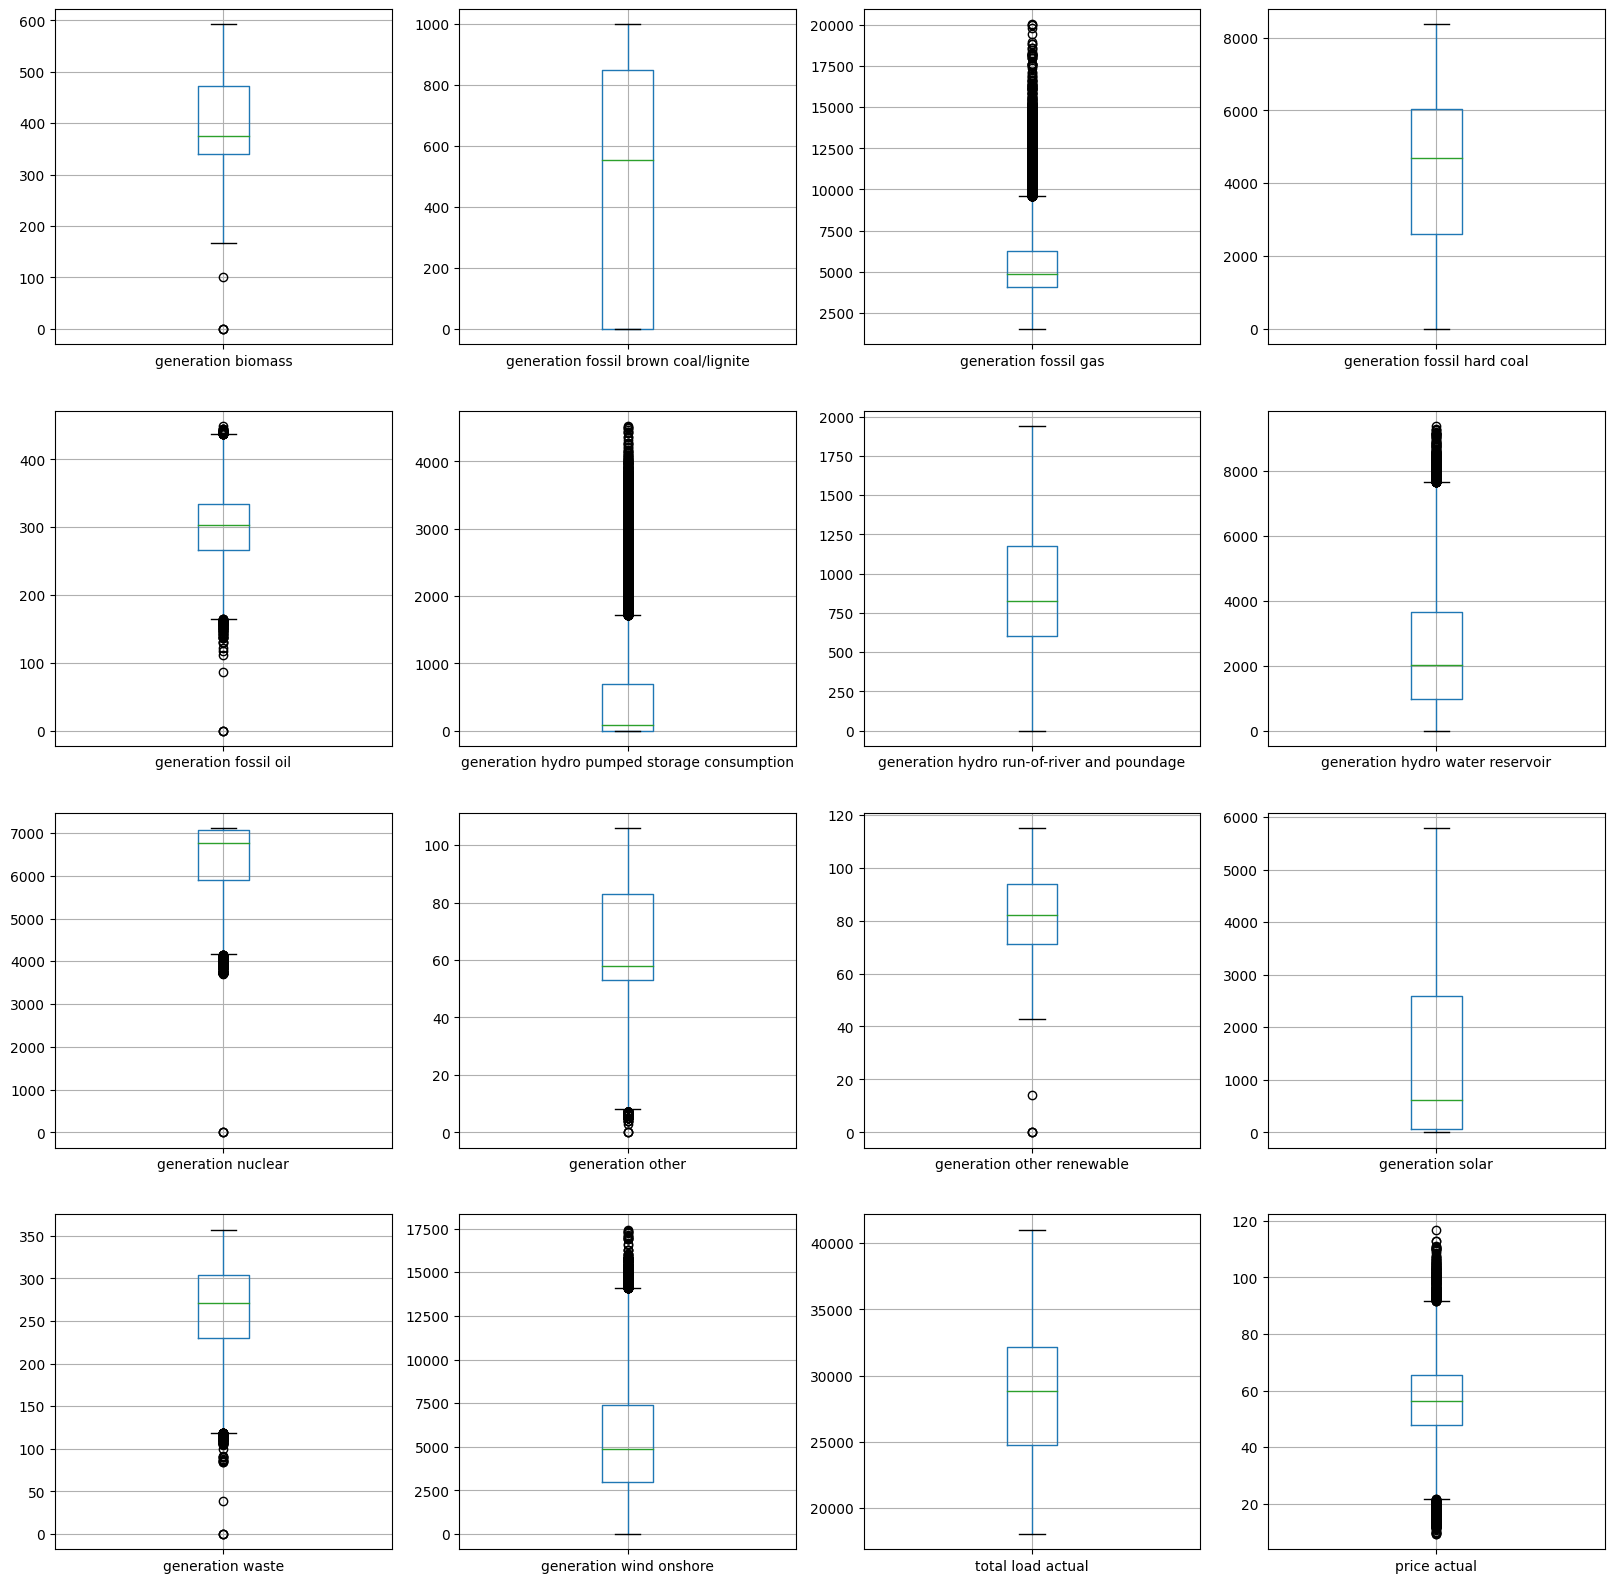

In [12]:
cols = df_train.columns
fig, axs = plt.subplots(4, 4, figsize=(20, 20))

for i, col in enumerate(df_train.columns):
    df_train.boxplot([col], ax=axs[i // 4, i % 4])


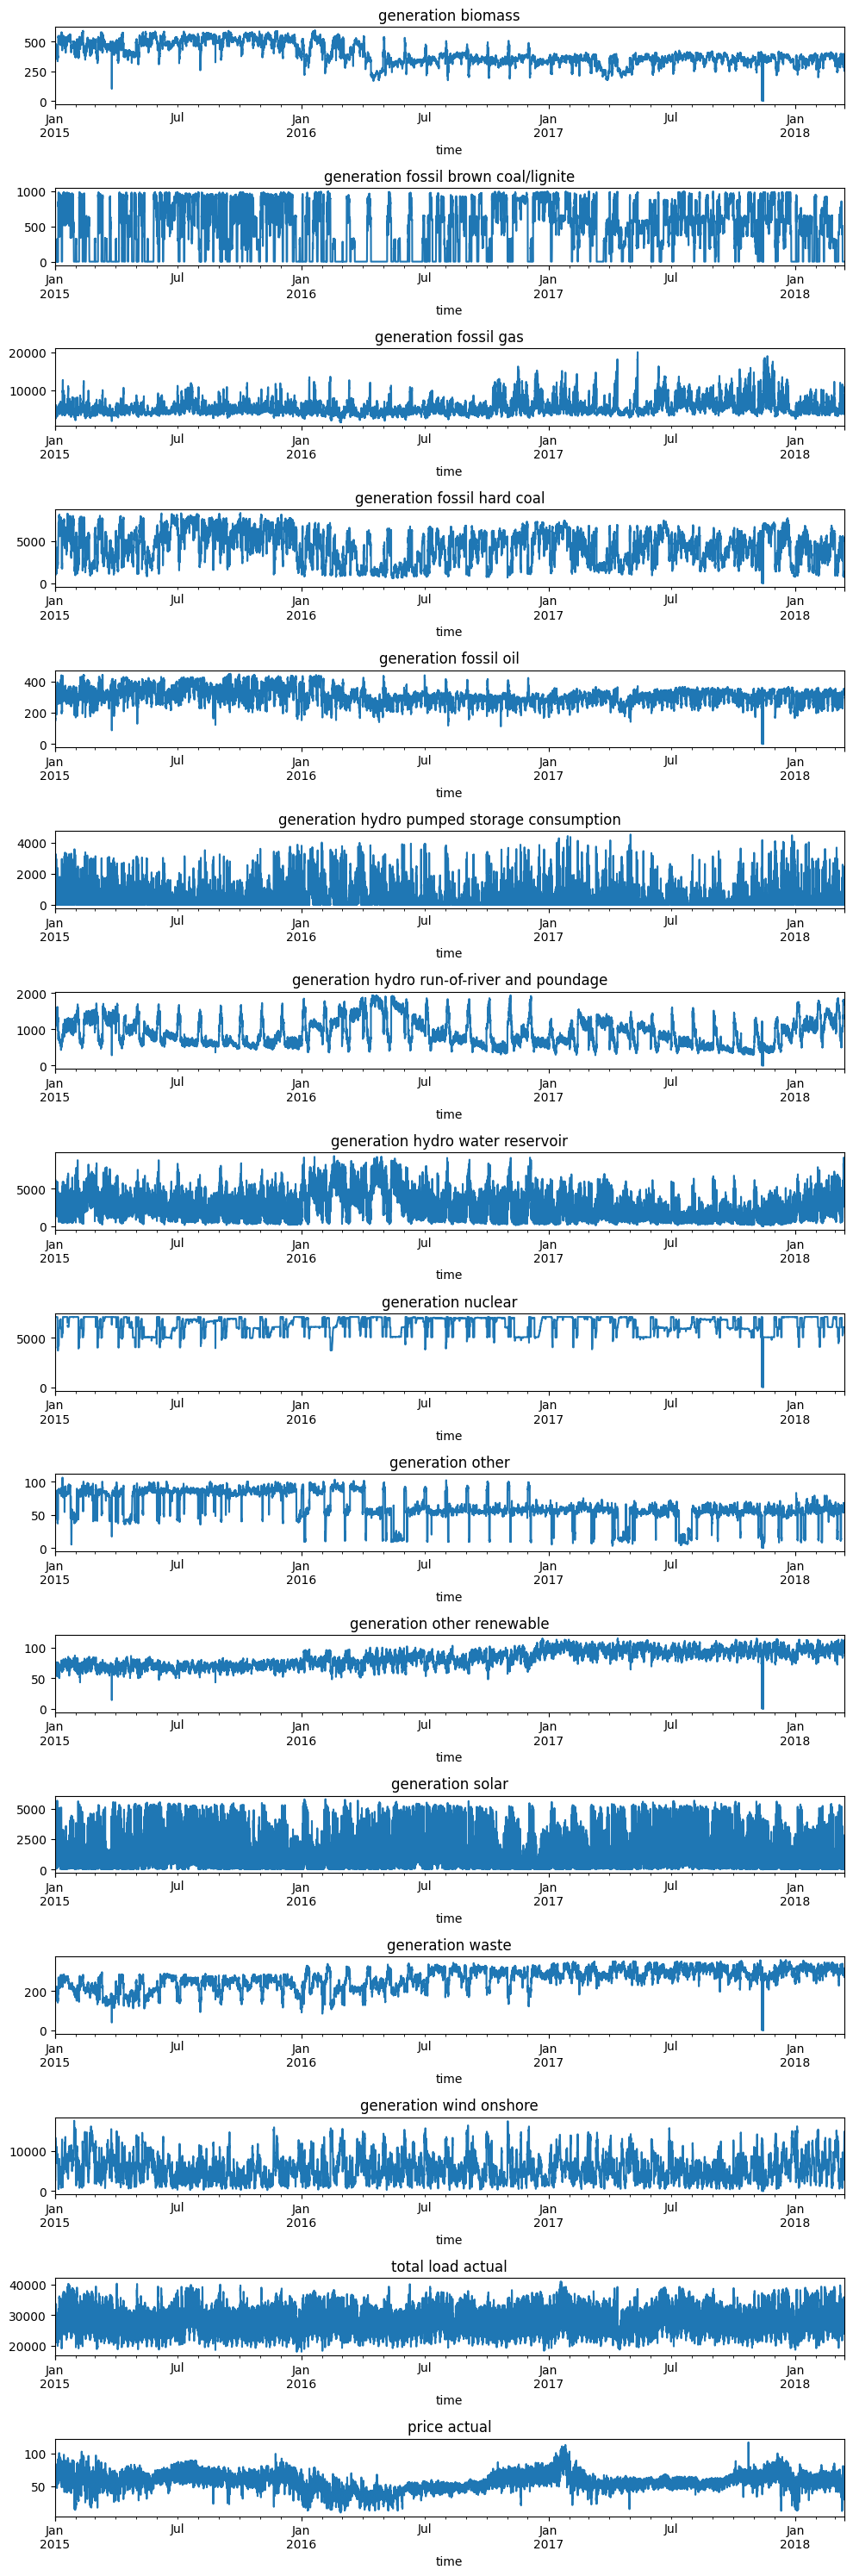

In [16]:
cols = df_train.columns
fig, axs = plt.subplots(len(cols),1, figsize=(10, 30))

for i, col in enumerate(df_train.columns):
    df_train.plot(y= col, ax=axs[i], title=col)
    axs[i].get_legend().remove()
    
plt.tight_layout()

In [17]:
df_train[df_train["generation waste"] == 0.0]

,generation biomass,generation fossil brown coal/lignite,generation fossil gas,generation fossil hard coal,generation fossil oil,generation hydro pumped storage consumption,generation hydro run-of-river and poundage,generation hydro water reservoir,generation nuclear,generation other,generation other renewable,generation solar,generation waste,generation wind onshore,total load actual,price actual
time,,,,,,,,,,,,,,,,
2017-11-12 20:00:00+00:00,0.0,0.0,6899.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,36562.0,67.66
2017-11-14 11:00:00+00:00,0.0,0.0,10064.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,66.17
2017-11-14 18:00:00+00:00,0.0,0.0,12336.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,75.45


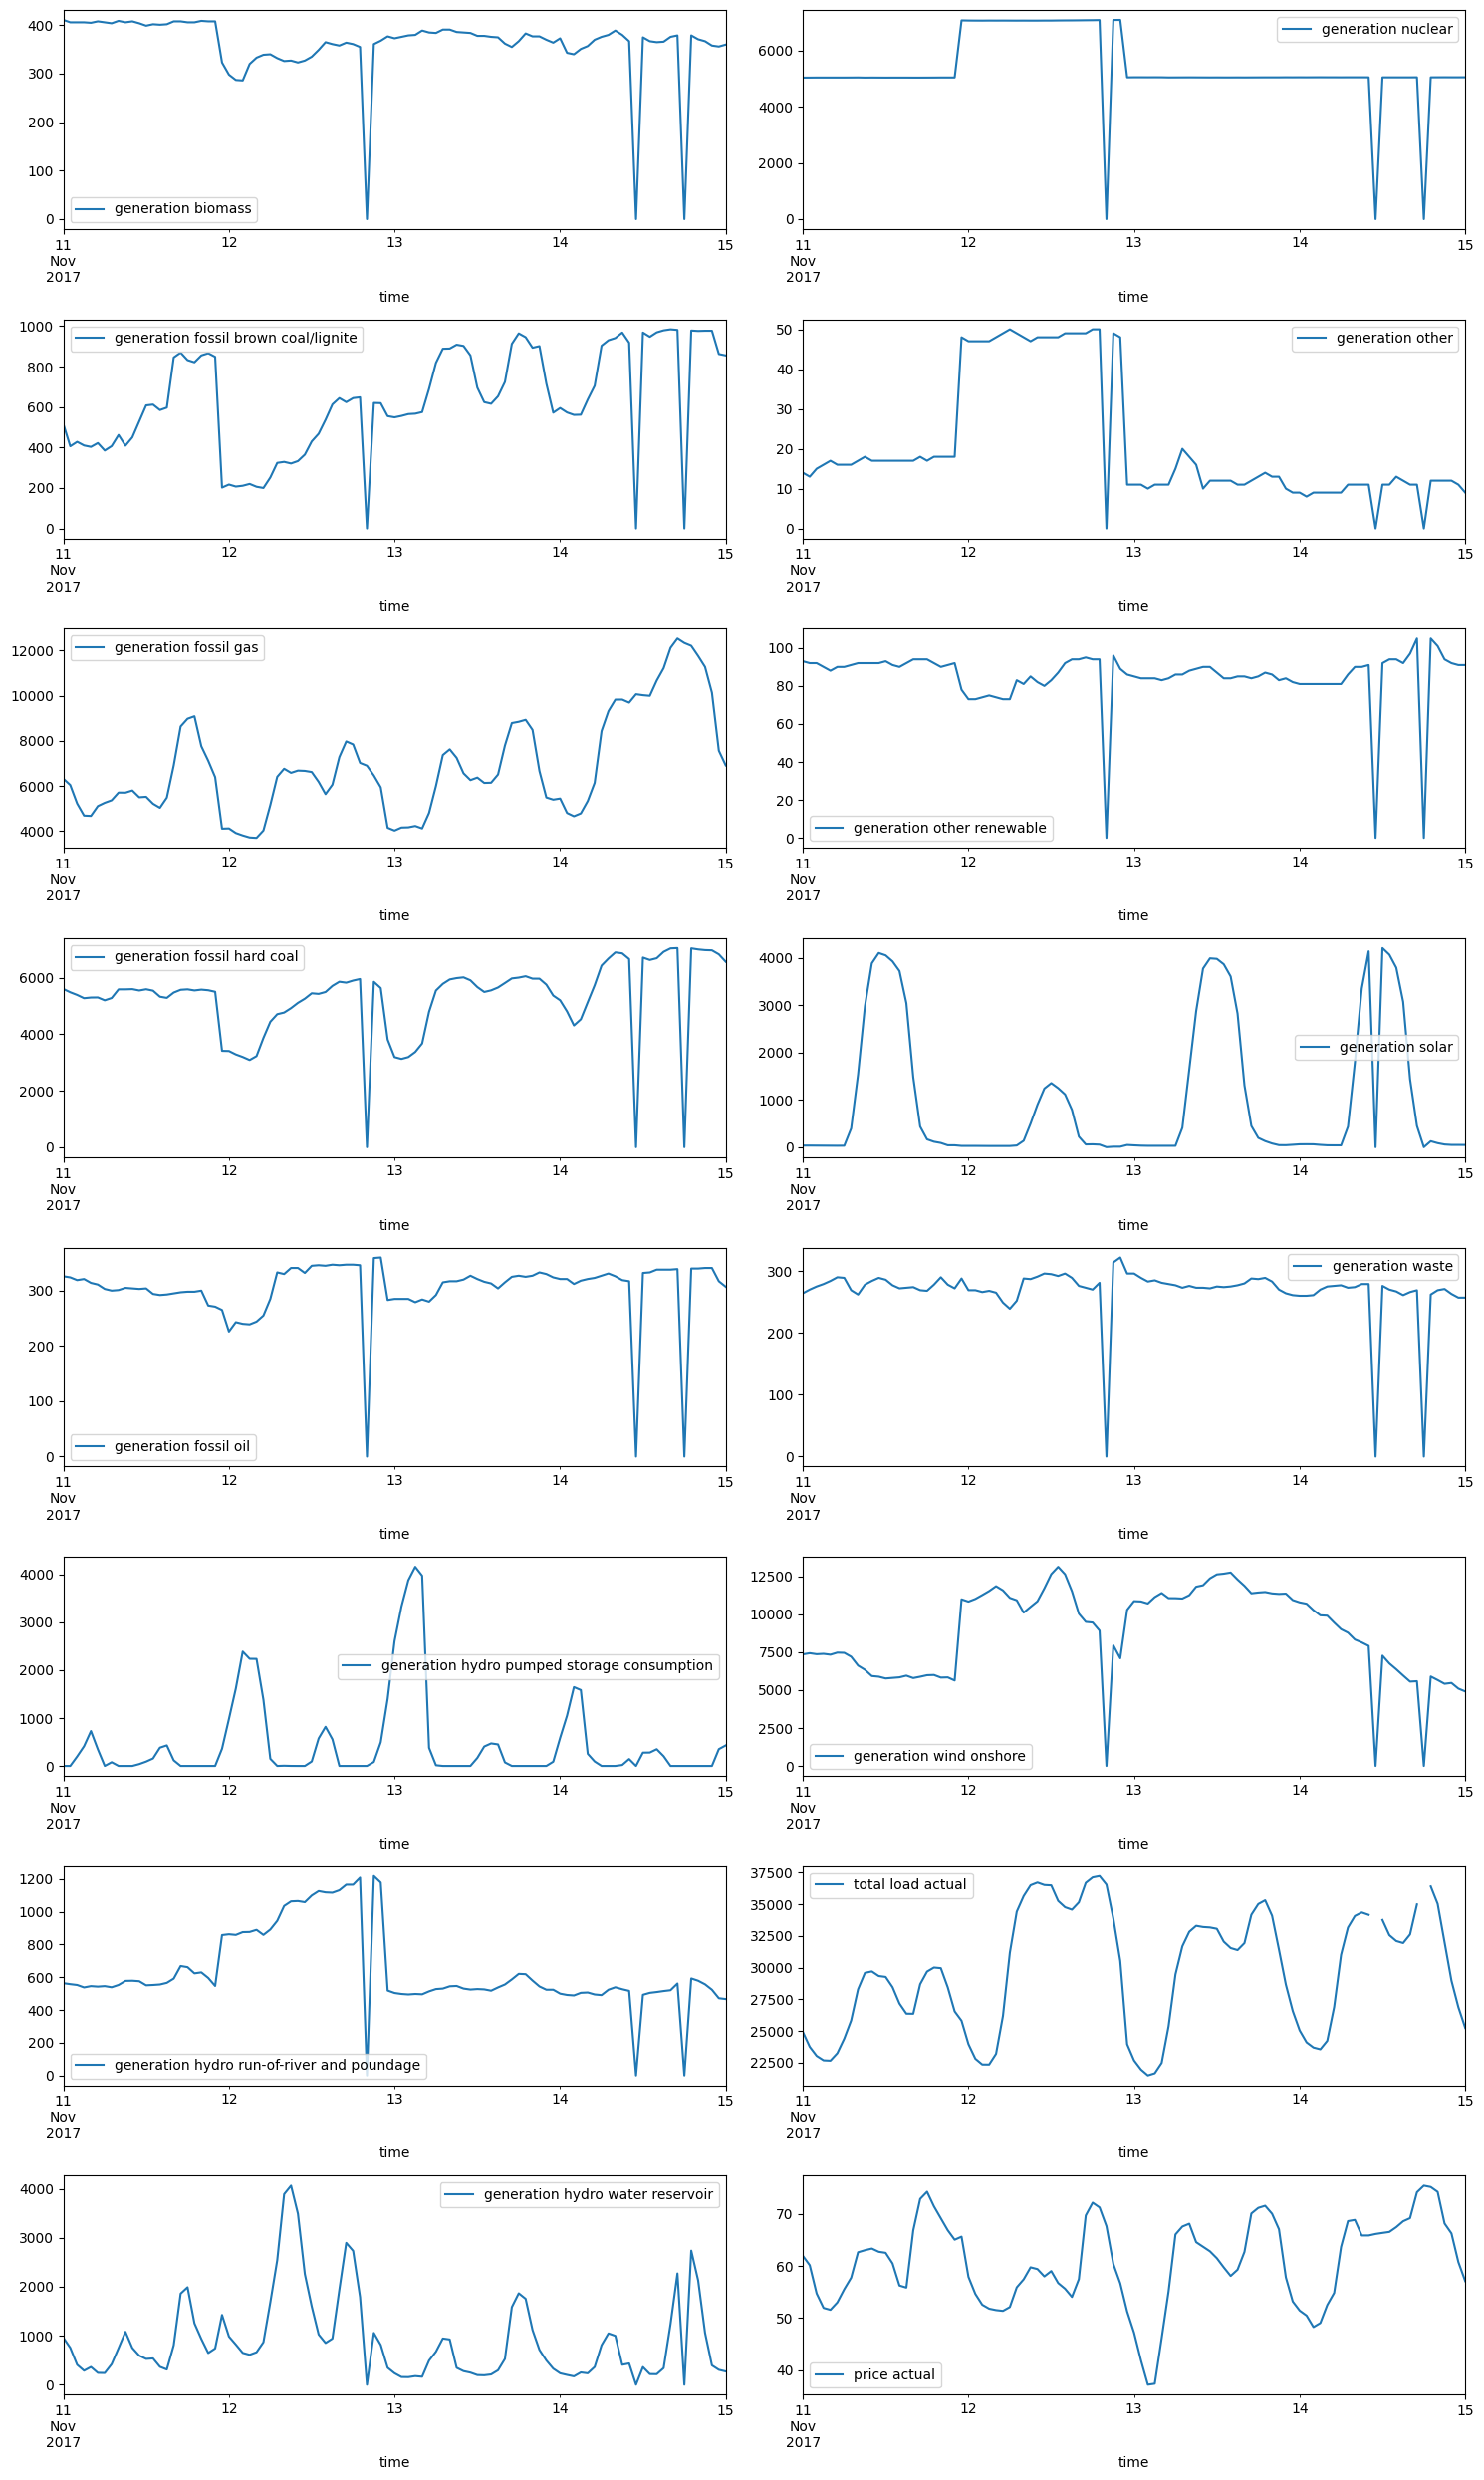

In [18]:
_ind = (df_train.index >= '2017-11-11') & (df_train.index <= '2017-11-15')

cols = df_train.columns
fig, axs = plt.subplots(8, 2, figsize=(15, 25))

for i, col in enumerate(df_train.columns):
    df_train[_ind].plot(y= col, ax=axs[i % 8, i // 8 ])
    
plt.tight_layout()

In [19]:
are_values_all_zero = (df_train[df_train["generation waste"] == 0.0]==0).all()
zero_cols = list(are_values_all_zero.index[are_values_all_zero.values])
are_values_all_zero

generation biomass                              True
generation fossil brown coal/lignite            True
generation fossil gas                          False
generation fossil hard coal                     True
generation fossil oil                           True
generation hydro pumped storage consumption     True
generation hydro run-of-river and poundage      True
generation hydro water reservoir                True
generation nuclear                              True
generation other                                True
generation other renewable                      True
generation solar                                True
generation waste                                True
generation wind onshore                         True
total load actual                              False
price actual                                   False
dtype: bool

In [20]:
outlier_ind = df_train[df_train["generation waste"] == 0.0].index
df_train.loc[outlier_ind, zero_cols] = np.nan

In [21]:
(df_train == 0).sum()

generation biomass                                 0
generation fossil brown coal/lignite            7873
generation fossil gas                              0
generation fossil hard coal                        0
generation fossil oil                              0
generation hydro pumped storage consumption    10102
generation hydro run-of-river and poundage         0
generation hydro water reservoir                   0
generation nuclear                                 0
generation other                                   0
generation other renewable                         0
generation solar                                   0
generation waste                                   0
generation wind onshore                            0
total load actual                                  0
price actual                                       0
dtype: int64

In [22]:
df_train.isna().sum()

generation biomass                             21
generation fossil brown coal/lignite           20
generation fossil gas                          17
generation fossil hard coal                    20
generation fossil oil                          21
generation hydro pumped storage consumption    21
generation hydro run-of-river and poundage     21
generation hydro water reservoir               20
generation nuclear                             19
generation other                               20
generation other renewable                     20
generation solar                               20
generation waste                               21
generation wind onshore                        20
total load actual                              34
price actual                                    0
dtype: int64

In [24]:
df_train_na = df_train[df_train.isna().any(axis=1)]
df_train_na.head()

,generation biomass,generation fossil brown coal/lignite,generation fossil gas,generation fossil hard coal,generation fossil oil,generation hydro pumped storage consumption,generation hydro run-of-river and poundage,generation hydro water reservoir,generation nuclear,generation other,generation other renewable,generation solar,generation waste,generation wind onshore,total load actual,price actual
time,,,,,,,,,,,,,,,,
2015-01-05 02:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21182.0,59.68
2015-01-05 11:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,79.14
2015-01-05 12:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,73.95
2015-01-05 13:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,71.93
2015-01-05 14:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,71.50


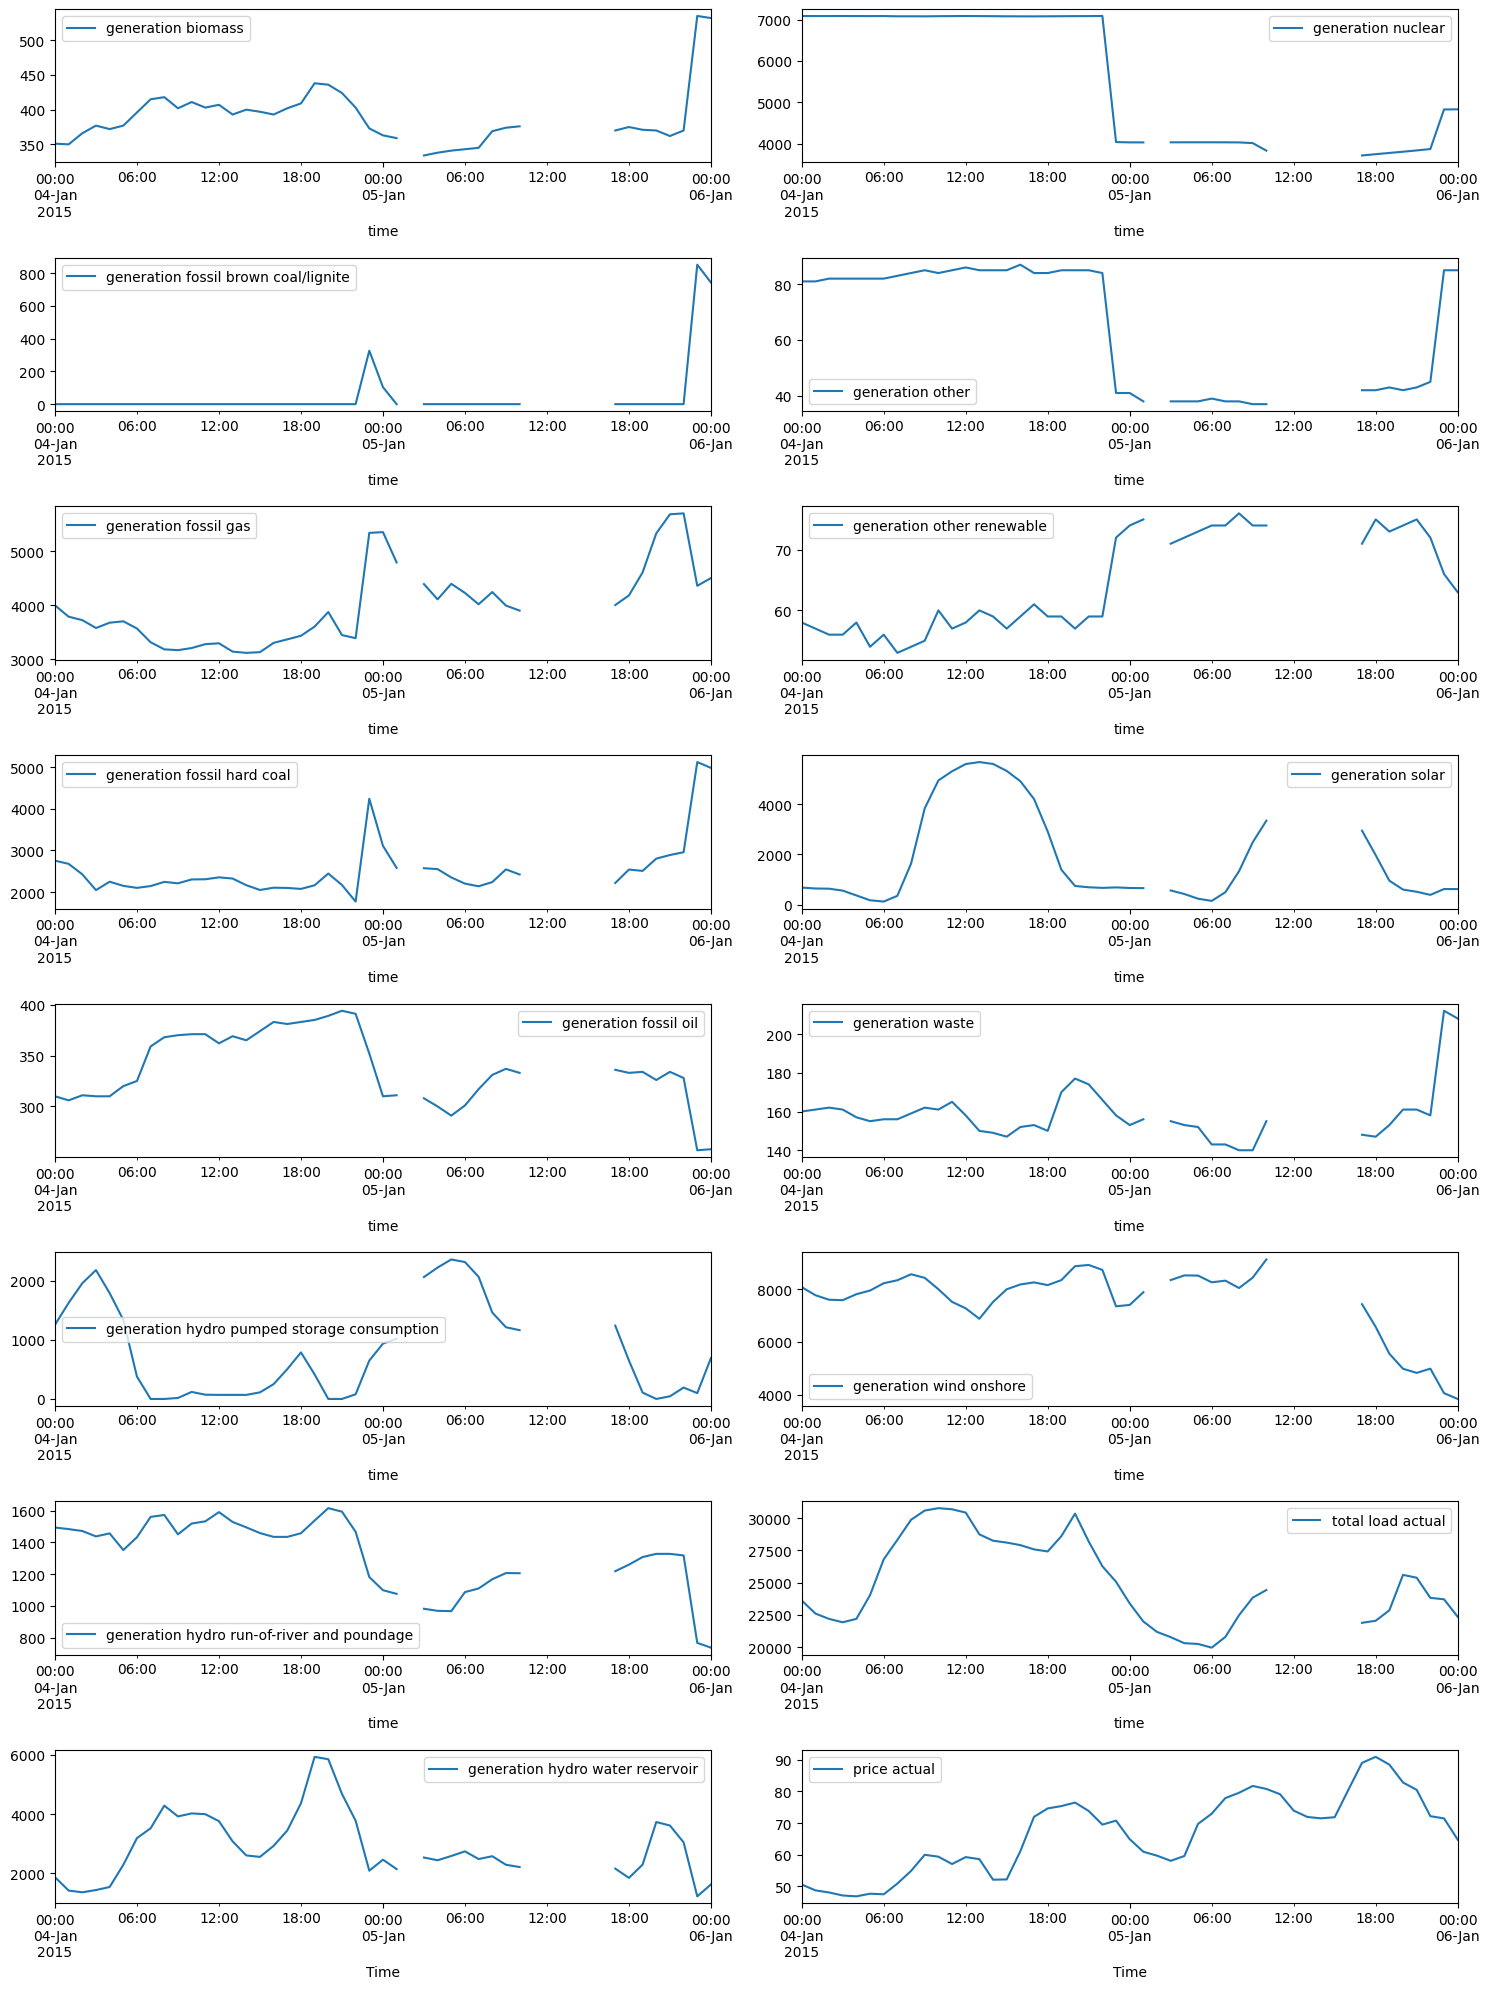

In [25]:
_ind = (df_train.index >= '2015-01-04') & (df_train.index <= '2015-01-06')

cols = df_train.columns
fig, axs = plt.subplots(8, 2, figsize=(15, 20))

for i, col in enumerate(df_train.columns):
    df_train[_ind].plot(y= col, ax=axs[i % 8, i // 8 ])
    
plt.tight_layout()

In [26]:
df_train.interpolate(method='linear', limit_direction='forward', inplace=True)

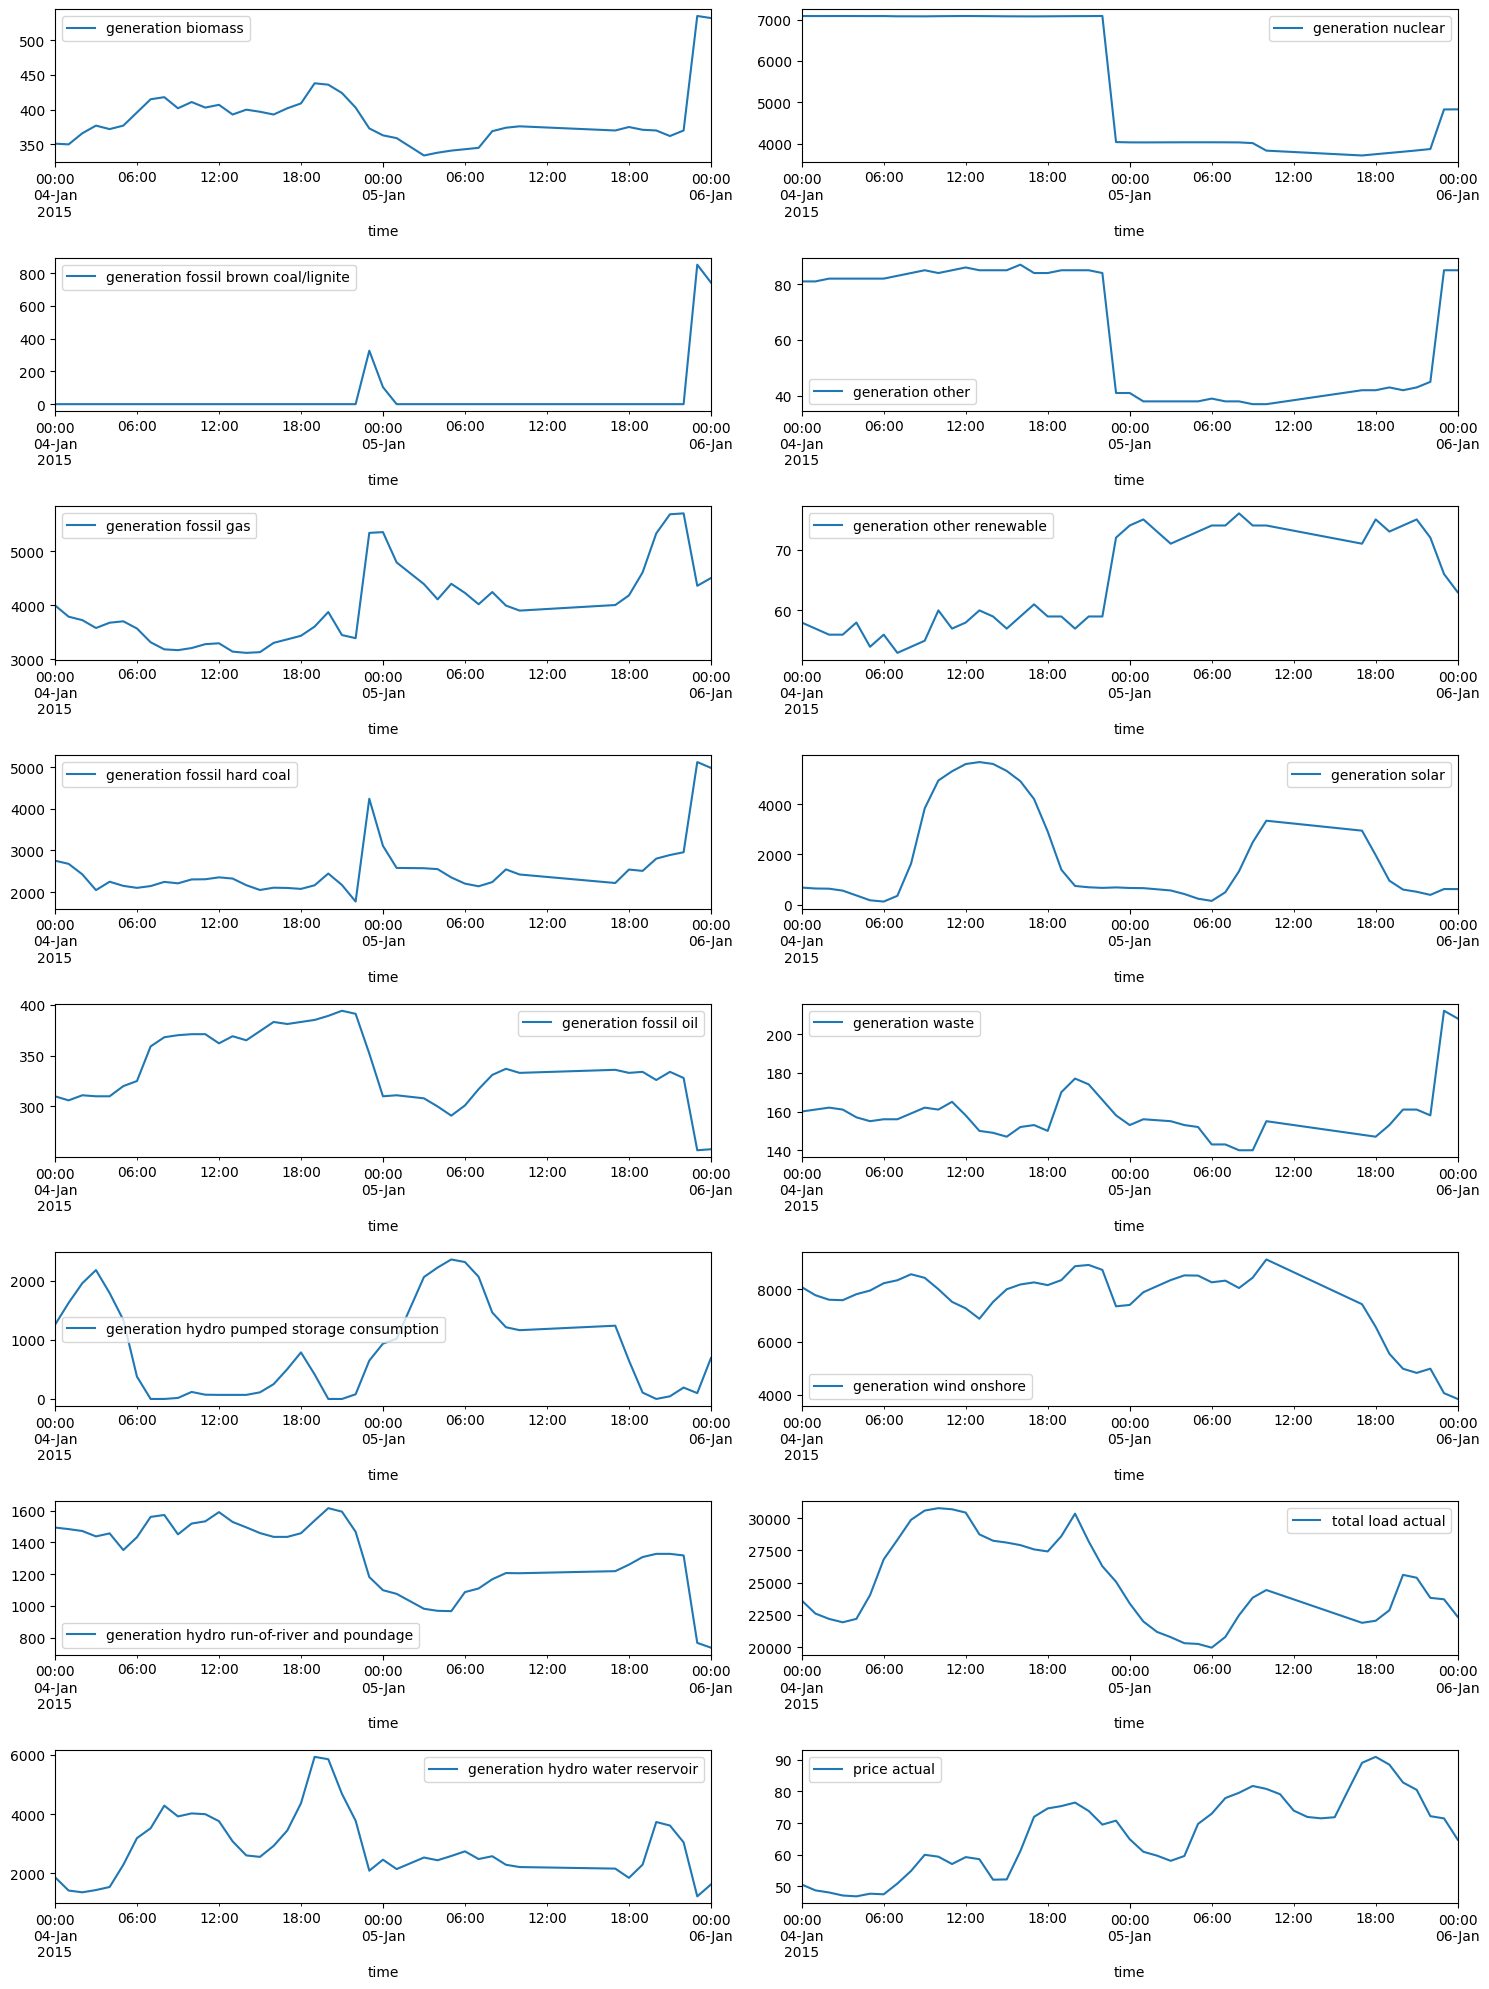

In [27]:
_ind = (df_train.index >= '2015-01-04') & (df_train.index <= '2015-01-06')

cols = df_train.columns
fig, axs = plt.subplots(8, 2, figsize=(15, 20))

for i, col in enumerate(df_train.columns):
    df_train[_ind].plot(y= col, ax=axs[i % 8, i // 8 ])
    
plt.tight_layout()

In [28]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 28051 entries, 2014-12-31 23:00:00+00:00 to 2018-03-14 17:00:00+00:00
Data columns (total 16 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   generation biomass                           28051 non-null  float64
 1   generation fossil brown coal/lignite         28051 non-null  float64
 2   generation fossil gas                        28051 non-null  float64
 3   generation fossil hard coal                  28051 non-null  float64
 4   generation fossil oil                        28051 non-null  float64
 5   generation hydro pumped storage consumption  28051 non-null  float64
 6   generation hydro run-of-river and poundage   28051 non-null  float64
 7   generation hydro water reservoir             28051 non-null  float64
 8   generation nuclear                           28051 non-null  float64
 9   generation other         

In [29]:
(df_train == 0).sum()

generation biomass                                 0
generation fossil brown coal/lignite            7880
generation fossil gas                              0
generation fossil hard coal                        0
generation fossil oil                              0
generation hydro pumped storage consumption    10110
generation hydro run-of-river and poundage         0
generation hydro water reservoir                   0
generation nuclear                                 0
generation other                                   0
generation other renewable                         0
generation solar                                   0
generation waste                                   0
generation wind onshore                            0
total load actual                                  0
price actual                                       0
dtype: int64